# EDA companion: problem formulation and time-series foundations

This notebook sits beside eda.ipynb. The main report builds a regime
classifier and treats that framing as given. Here the framing is earned. The
series is characterised from the ground up, the default time-series
approaches are tried, and the modelling choice is justified against them.

It is self-contained. It loads the same 1-minute matrix and runs its own
analysis. Nothing here depends on eda.ipynb.

Order of work:
1. Setup and data
2. Integration order: is the price I(1)?
3. Serial structure: autocorrelation of returns and of volatility
4. The default forecast: random walk against ARIMA
5. Where the predictability is: volatility
6. Direction: the hard part
7. Why classification, not a pure time-series model
8. Overlapping windows and honest confidence intervals
9. Conclusion

## 1. Setup and data

Load the matrix shards, build a daily session panel, and keep the 1-minute
returns. Everything downstream is derived from these.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import glob
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

SHARDS = sorted(glob.glob("data/matrix_*.parquet"))
assert SHARDS, "no matrix shards in data/ (see README)"
df = pl.concat([pl.read_parquet(s) for s in SHARDS]).sort(["generic_symbol", "ts_event"])
print(f"rows: {df.height:,}   cols: {df.width}")
print("range:", df["ts_event"].min(), "to", df["ts_event"].max())

# Daily session panel, built here so the notebook stands alone.
daily = (df.lazy()
         .group_by(pl.col("session_id").alias("day"))
         .agg([pl.col("close").last().alias("close"),
               pl.col("vol_60m").mean().alias("rv")])
         .sort("day").collect().to_pandas())
daily["day"] = pd.to_datetime(daily["day"])
daily["ret"] = daily["close"].pct_change()
print(f"daily sessions: {len(daily):,}")

rows: 5,280,818   cols: 73
range: 2010-06-06 22:00:00+00:00 to 2025-12-12 21:58:00+00:00
daily sessions: 3,942


## 2. Integration order: is the price I(1)?

A forecasting model has to know what kind of series it faces. The price level
and its first difference behave differently, and that difference decides the
order of differencing in any ARIMA.

ADF and KPSS carry opposite nulls, so reading them together is safer than
either alone. ADF asks whether there is a unit root; KPSS asks whether the
series is stationary around a fixed level. The expectation for a traded
price: the level holds a unit root and fails stationarity, the return holds
neither. That makes the price integrated of order one, I(1), and the return
I(0).

In [2]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings as _w

def order_tests(x, name):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    adf_p = adfuller(x, autolag="AIC")[1]
    with _w.catch_warnings():
        _w.simplefilter("ignore")            # kpss clips and warns at its p-value bounds
        kpss_p = kpss(x, regression="c", nlags="auto")[1]
    return {"series": name, "n": len(x),
            "ADF p": round(adf_p, 3),  "ADF": "stationary" if adf_p < 0.05 else "unit root",
            "KPSS p": round(kpss_p, 3), "KPSS": "stationary" if kpss_p > 0.05 else "non-stationary"}

ret1m = df.filter(pl.col("is_us") == 1)["ret_1m"].drop_nulls().to_numpy()
tbl = pd.DataFrame([
    order_tests(daily["close"].values, "price level (daily)"),
    order_tests(daily["ret"].values,   "return (daily)"),
    order_tests(ret1m[:200_000],       "return (1-min, US sample)"),
])
print(tbl.to_string(index=False))
print("\nThe level is I(1), the return I(0). Any ARIMA on the price needs d = 1.")

                   series      n  ADF p        ADF  KPSS p           KPSS
      price level (daily)   3942  0.209  unit root    0.01 non-stationary
           return (daily)   3941  0.000 stationary    0.10     stationary
return (1-min, US sample) 200000  0.000 stationary    0.10     stationary

The level is I(1), the return I(0). Any ARIMA on the price needs d = 1.


## 3. Serial structure: returns against volatility

With the order settled, the next question is whether the stationary part, the
return, carries any linear structure to fit. The autocorrelation and partial
autocorrelation answer it. A flat ACF and PACF mean no AR or MA terms help,
and an ARIMA on returns collapses to white noise.

The same plot on absolute returns is the counterweight. If it is large and
slow, the variance has structure even where the mean does not. That is the
ARCH effect, and Engle's test puts a number on it. Computed on US-session
bars, so the overnight zero-prints do not manufacture short-lag structure.

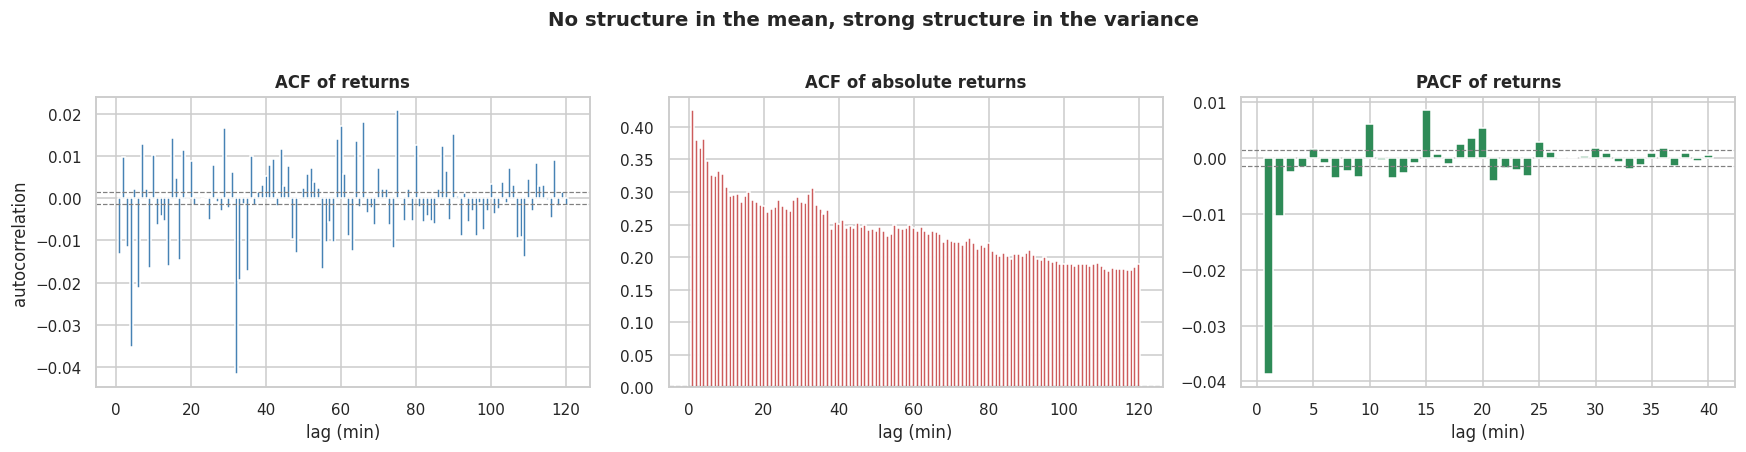

return ACF lag1/5/60:    -0.013 +0.002 +0.017
absolute ACF lag1/5/60:  +0.425 +0.347 +0.244
Engle ARCH-LM (20 lags): stat 4,890  p 0.  ARCH effects present.


In [3]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import het_arch

absret = np.abs(ret1m)
NL = 120
a_ret = acf(ret1m, nlags=NL, fft=True)
a_abs = acf(absret, nlags=NL, fft=True)
p_ret = pacf(ret1m[:1_000_000], nlags=40, method="ywm")
band = 1.96 / np.sqrt(len(ret1m))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar(range(1, NL + 1), a_ret[1:], color="steelblue")
ax[0].axhline(band, color="grey", ls="--", lw=0.8); ax[0].axhline(-band, color="grey", ls="--", lw=0.8)
ax[0].set_title("ACF of returns"); ax[0].set_xlabel("lag (min)"); ax[0].set_ylabel("autocorrelation")
ax[1].bar(range(1, NL + 1), a_abs[1:], color="indianred")
ax[1].axhline(band, color="grey", ls="--", lw=0.8)
ax[1].set_title("ACF of absolute returns"); ax[1].set_xlabel("lag (min)")
ax[2].bar(range(1, len(p_ret)), p_ret[1:], color="seagreen")
ax[2].axhline(band, color="grey", ls="--", lw=0.8); ax[2].axhline(-band, color="grey", ls="--", lw=0.8)
ax[2].set_title("PACF of returns"); ax[2].set_xlabel("lag (min)")
fig.suptitle("No structure in the mean, strong structure in the variance",
             fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

lm_stat, lm_p, _, _ = het_arch(ret1m[:100_000], nlags=20)
print(f"return ACF lag1/5/60:    {a_ret[1]:+.3f} {a_ret[5]:+.3f} {a_ret[60]:+.3f}")
print(f"absolute ACF lag1/5/60:  {a_abs[1]:+.3f} {a_abs[5]:+.3f} {a_abs[60]:+.3f}")
print(f"Engle ARCH-LM (20 lags): stat {lm_stat:,.0f}  p {lm_p:.2g}.  ARCH effects present.")

## 4. The default forecast: random walk against ARIMA

The natural way to forecast a price is to model it directly. With the level
I(1) and the return white, a pure ARIMA should have nothing to forecast on
the mean: whatever order it fits, it should not beat the random walk out of
sample. This section checks that rather than asserting it.

First an order search by AIC on the daily return. An in-sample criterion can
still pick a non-trivial order, fitting noise. What settles it is the
walk-forward one-step comparison against the naive forecast, which for a
return is simply zero. If the model does not beat that, a pure time-series
model adds nothing to the mean.

In [4]:
from statsmodels.tsa.arima.model import ARIMA

dret = daily["ret"].dropna().values
search = []
for p in range(4):
    for q in range(4):
        try:
            search.append((p, q, ARIMA(dret, order=(p, 0, q)).fit().aic))
        except Exception:
            pass
search = pd.DataFrame(search, columns=["p", "q", "AIC"]).sort_values("AIC")
print("ARIMA order search on daily returns (lowest AIC first):")
print(search.head(6).to_string(index=False))
best = (int(search.iloc[0]["p"]), int(search.iloc[0]["q"]))
print(f"\nbest by AIC: ARIMA(p={best[0]}, d=0, q={best[1]})")

/home/hans/miniforge3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/hans/miniforge3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA order search on daily returns (lowest AIC first):
 p  q           AIC
 2  3 -17788.831359
 3  3 -17786.700323
 2  2 -17783.896337
 3  0 -17780.247792
 2  0 -17779.449772
 0  3 -17779.054504

best by AIC: ARIMA(p=2, d=0, q=3)


In [5]:
# Walk-forward one-step forecast over the last fifth of the sample, params
# fixed after the initial fit (append with refit=False rolls the state).
split = int(len(dret) * 0.8)
train, test = dret[:split], dret[split:]
res = ARIMA(train, order=(best[0], 0, best[1])).fit()
preds = []
for x in test:
    preds.append(res.forecast(1)[0])
    res = res.append([x], refit=False)
preds = np.array(preds)
naive = np.zeros_like(test)              # random walk on price = zero forecast on return

def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
r_arima, r_naive = rmse(preds, test), rmse(naive, test)
print(f"out-of-sample one-step RMSE on daily returns ({len(test)} steps):")
print(f"  ARIMA({best[0]},0,{best[1]}):  {r_arima:.5f}")
print(f"  random walk    :  {r_naive:.5f}")
print(f"  ratio          :  {r_arima / r_naive:.4f}   (1.0 = no improvement on the mean)")

# Same question at the 60-minute trading horizon: the AR(1) slope on
# non-overlapping 60-min returns, which is the ARIMA(1,0,0) coefficient.
from statsmodels.tsa.ar_model import AutoReg
H = 60
lc = pl.col("close").log()
r60 = (df.select((lc.shift(-H).over("source_contract") - lc).alias("r"))
         .with_row_index("i").drop_nulls("r")
         .filter(pl.col("i") % H == 0)["r"].to_numpy())
ar1 = AutoReg(r60, lags=1, old_names=False).fit().params[1]
print(f"\n60-min non-overlapping returns: {len(r60):,} windows, AR(1) slope {ar1:+.3f} (near zero)")

out-of-sample one-step RMSE on daily returns (789 steps):
  ARIMA(2,0,3):  0.01937
  random walk    :  0.01929
  ratio          :  1.0046   (1.0 = no improvement on the mean)

60-min non-overlapping returns: 87,827 windows, AR(1) slope -0.003 (near zero)


## 5. Where the predictability is: volatility

The mean is a random walk, but section 3 found strong structure in absolute
returns. That structure is forecastable. A realized-volatility series is
persistent, and a one-step model of it beats a flat guess, which the return
forecast could not do. The predictable quantity in this market is risk, not
direction.

In [6]:
from statsmodels.tsa.ar_model import AutoReg

# Daily realized volatility on a log scale, with an AR(1) one-step forecast.
rv = np.log(daily["rv"].replace(0, np.nan).dropna().values)
sp = int(len(rv) * 0.8)
rv_tr, rv_te = rv[:sp], rv[sp:]
fit = AutoReg(rv_tr, lags=1, old_names=False).fit()
c, phi = fit.params[0], fit.params[1]
pred = c + phi * rv[sp - 1:-1]           # one-step-ahead from the previous realized value
const = np.full_like(rv_te, rv_tr.mean())

def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
print(f"log realized-vol AR(1): persistence phi = {phi:.3f}")
print(f"out-of-sample one-step RMSE ({len(rv_te)} steps):")
print(f"  AR(1)          : {rmse(pred, rv_te):.4f}")
print(f"  constant (mean): {rmse(const, rv_te):.4f}")
print(f"  ratio          : {rmse(pred, rv_te) / rmse(const, rv_te):.3f}   (below 1 = volatility is forecastable)")

log realized-vol AR(1): persistence phi = 0.914
out-of-sample one-step RMSE (789 steps):
  AR(1)          : 0.1775
  constant (mean): 0.3440
  ratio          : 0.516   (below 1 = volatility is forecastable)


## 6. Direction: the hard part

Direction is what a trader wants and what a classifier of UP against DOWN is
trying to call. It is also the part with no structure. The sign of the next
60-minute return is close to a coin flip, and the momentum rule, betting that
the next move follows the last, does no better.

In [7]:
both = (df.select([
            (lc - lc.shift(H).over("source_contract")).alias("b"),
            (lc.shift(-H).over("source_contract") - lc).alias("f")])
        .with_row_index("i").drop_nulls(["b", "f"])
        .filter(pl.col("i") % H == 0))
b, f = both["b"].to_numpy(), both["f"].to_numpy()
print(f"non-overlapping 60-min windows: {len(f):,}")
print(f"base rate, next move up:        {np.mean(f > 0):.3f}")
print(f"momentum rule directional hit:  {np.mean(np.sign(b) == np.sign(f)):.3f}   (0.50 = chance)")

non-overlapping 60-min windows: 87,640
base rate, next move up:        0.493
momentum rule directional hit:  0.462   (0.50 = chance)


## 7. Why classification, not a pure time-series model

Putting the pieces together answers the question the main report skipped.

A pure time-series model forecasts the level or the return. The level is a
random walk and the return is white, so whatever order an ARIMA fits in
sample, it does not beat the random walk out of sample (section 4). There is
no edge to take on the first moment.

Volatility is forecastable (section 5), but it is the second moment, not the
trading direction, and acting on it needs options, not a position in the
front contract.

Direction is near chance (section 6). A model of the sign has nothing to
learn from the past sign.

Given that, the regime classifier in eda.ipynb is a deliberate change of
target, not an oversight. It does three things a return forecast cannot. It
divides out the volatility that dominates raw returns, so the label is not a
disguised volatility detector. It adds path efficiency, a property the level
never sees. And it allows abstention through NO_TRADE, so the model commits
only on high-conviction windows. It also brings features beyond price, open
interest, term structure, and implied vol, which a univariate ARIMA cannot
use.

The honest outcome is that the regime still sits on the direction axis, and
the classifier also lands at chance. The reframing was a reasonable
hypothesis that did not pay off. Its value is that the negative now arrives by
two independent routes, the random walk on the mean and the classifier on the
regime, with one positive alongside, the forecastable volatility. That is a
complete characterisation, and it is why the baseline in the main report is
the right endpoint rather than a strawman.

## 8. Overlapping windows and honest confidence intervals

The label is assigned every minute over a 60-minute window, so neighbouring
labels overlap by 59 minutes. The independent unit is the non-overlapping
window, of which there are tens of thousands, not millions. A confidence
interval has to be built on those, or it understates the noise by a large
factor.

The bootstrap below resamples the non-overlapping windows and rebuilds two
statistics: the momentum autocorrelation and the TPS ranking of the reference
regime. Both intervals straddle the no-skill line. The small gaps from chance
seen in the main report are inside the noise.

In [8]:
from sklearn.metrics import roc_auc_score

# Reference regime, recomputed here so the notebook stands alone.
rc = df.filter((~pl.col("near_roll")) & (~pl.col("fwd_crosses_roll"))).drop_nulls(["fwd_radj_60", "fwd_E_60"])
ra, ee = rc["fwd_radj_60"].to_numpy(), rc["fwd_E_60"].to_numpy()
qv = (np.quantile(ra, .70), np.quantile(ra, .30), np.quantile(ee, .60),
      np.quantile(np.abs(ra), .35), np.quantile(ee, .40))
df2 = df.with_columns(
    pl.when((pl.col("fwd_radj_60") > qv[0]) & (pl.col("fwd_E_60") > qv[2])).then(1)
      .when((pl.col("fwd_radj_60") < qv[1]) & (pl.col("fwd_E_60") > qv[2])).then(2)
      .when((pl.col("fwd_radj_60").abs() < qv[3]) & (pl.col("fwd_E_60") < qv[4])).then(0)
      .otherwise(3).alias("reg"))

win = (df2.select([
           "reg", "tps_60m",
           (lc - lc.shift(H).over("source_contract")).alias("b"),
           (lc.shift(-H).over("source_contract") - lc).alias("f")])
        .with_row_index("i").drop_nulls(["b", "f"])
        .filter(pl.col("i") % H == 0))
bb, ff = win["b"].to_numpy(), win["f"].to_numpy()
wreg, wtps = win["reg"].to_numpy(), win["tps_60m"].to_numpy()
keep = (wreg != 3) & np.isfinite(wtps)
idx_t = np.where(keep)[0]

def auc3(y, sc):
    out = [roc_auc_score((y == k).astype(int), sc) for k in (0, 1, 2)
           if (y == k).any() and not (y == k).all()]
    return float(np.mean(out)) if out else np.nan

rng = np.random.default_rng(0)
n, B = len(bb), 400
mom_bs, auc_bs = [], []
for _ in range(B):
    s = rng.integers(0, n, n)
    mom_bs.append(np.corrcoef(bb[s], ff[s])[0, 1])
    st = rng.choice(idx_t, len(idx_t))
    auc_bs.append(auc3(wreg[st], wtps[st]))
auc_bs = [a for a in auc_bs if np.isfinite(a)]

mlo, mhi = np.percentile(mom_bs, [2.5, 97.5])
alo, ahi = np.percentile(auc_bs, [2.5, 97.5])
print(f"non-overlapping windows: {n:,}   ({B} bootstrap resamples)")
print(f"momentum autocorr  95% CI: [{mlo:+.3f}, {mhi:+.3f}]   (0.00 is no skill)")
print(f"TPS-60 mean AUC    95% CI: [{alo:.3f}, {ahi:.3f}]   (0.500 is no skill)")

non-overlapping windows: 87,640   (400 bootstrap resamples)
momentum autocorr  95% CI: [-0.031, +0.029]   (0.00 is no skill)
TPS-60 mean AUC    95% CI: [0.500, 0.501]   (0.500 is no skill)


## 9. Conclusion

The series sets the ceiling before any model is chosen. The price is a random
walk, returns are white, and only volatility is forecastable. A pure
time-series model, ARIMA on the level or the return, does not beat the random
walk and adds nothing to direction. Forecasting volatility works but answers a
different question.

The regime classifier in eda.ipynb is the right response to that picture: a
decision-oriented target with abstention, conditioned on volatility, fed by
features a univariate model cannot use. That it still lands at chance is the
finding, and it is robust. The mean is unforecastable by ARIMA, the regime is
unforecastable by the classifier, and the bootstrap intervals on
non-overlapping windows sit across the no-skill line.

The main report carries the regime EDA and the baseline. This notebook is the
reason that baseline is the honest endpoint, reached after the simpler models
were tried, not assumed away.